In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

"""
 

"""
wine_df = pd.read_csv('/Users/rjha/code/github/ai-training/data/uci/wine/red.csv', sep=';')
print(wine_df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [11]:
# Compute mathematical relationship directly
correlation_matrix = wine_df.corr()

# Sort to see exactly what matters most to wine quality
print(correlation_matrix['quality'].sort_values(ascending=False))


quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


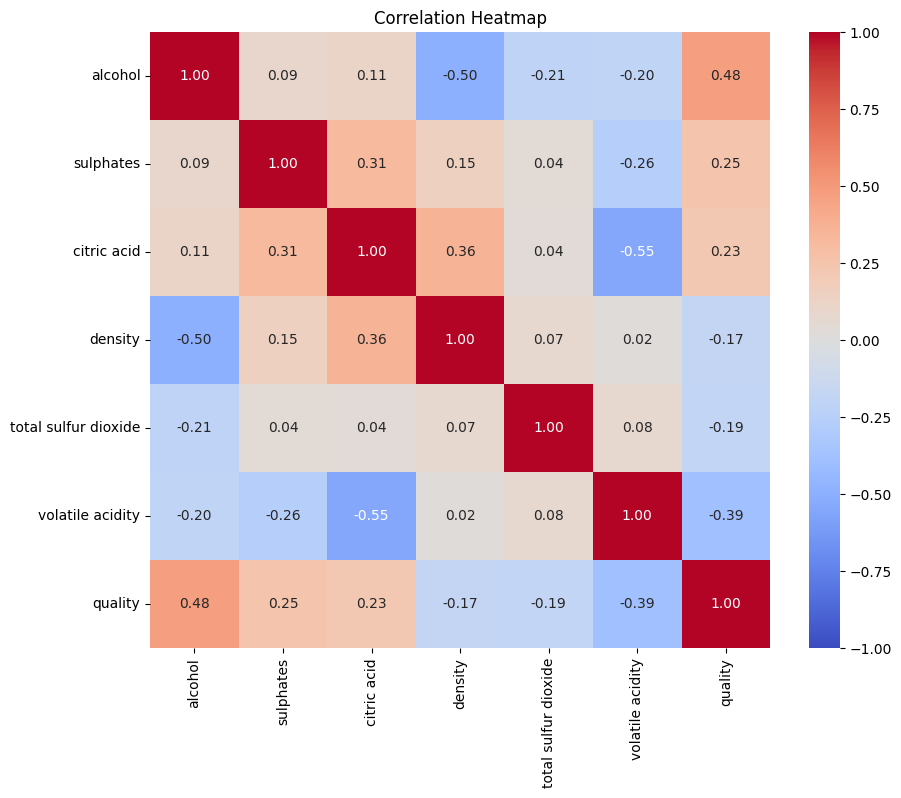

In [14]:
# plot heatmap 
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_df = wine_df[["alcohol", "sulphates", "citric acid", "density", "total sulfur dioxide", "volatile acidity", "quality"]]
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

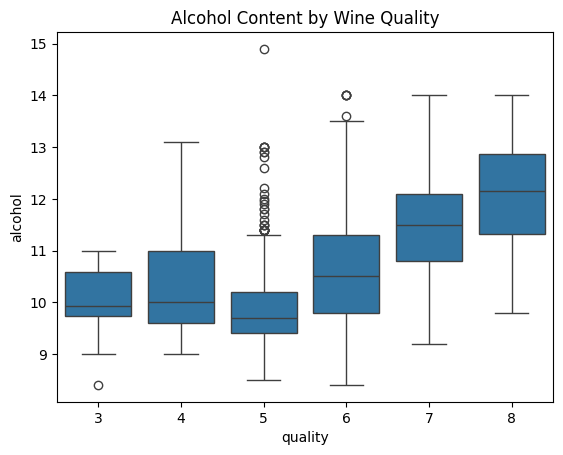

In [13]:
# Check how alcohol levels behave across each quality score
sns.boxplot(x='quality', y='alcohol', data=wine_df)
plt.title('Alcohol Content by Wine Quality')
plt.show()


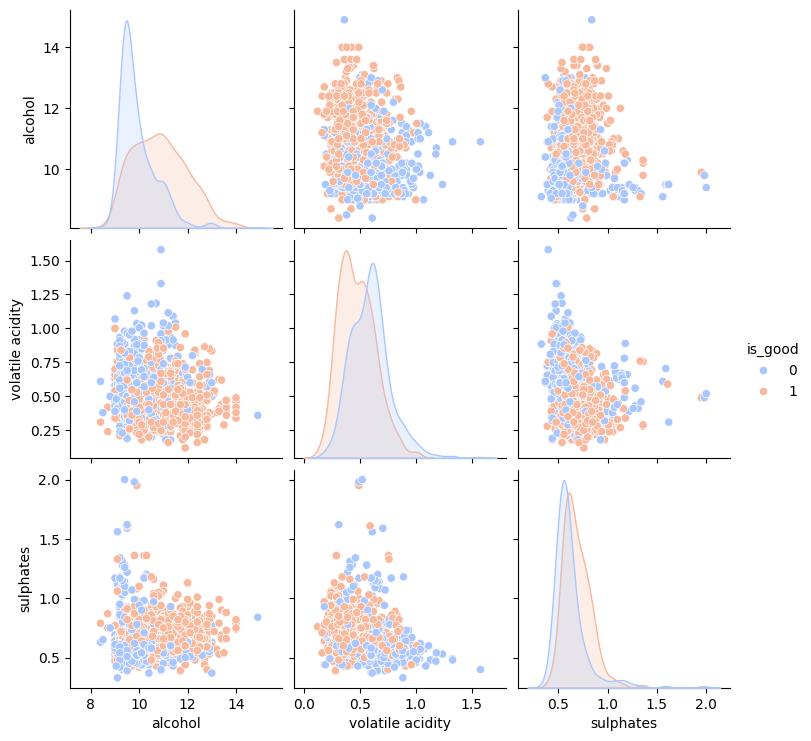

In [15]:
# Create a binary target: 1 for good wine (quality >= 6), 0 for bad wine (quality < 6)
wine_df['is_good'] = (wine_df['quality'] >= 6).astype(int)
# Select 3 key variables to plot against each other
sns.pairplot(wine_df[['alcohol', 'volatile acidity', 'sulphates', 'is_good']], hue='is_good', palette='coolwarm')
plt.show()
